In [178]:
import numpy as np
import matplotlib.pyplot as plt

In [179]:
def rhs(t, X):
    x, y = X

    return np.array([
        -0.5 * x + 20.0 * y,  # x'
        -20.0 * y             # y'
    ])

In [180]:
t0, T = 0.0, 3.0

X0 = np.array([0.0, 1.0])  # x(0)=0, y(0)=1

dt  = 0.01
n = int(np.ceil((T - t0) / dt))

# discrete time
t = np.linspace(t0, T, n)

# exact solution
y_exact = np.exp(-20.0 * t)
x_exact = (20.0 / 19.5) * np.exp(-0.5 * t) * (1.0 - np.exp(-19.5 * t))

# allocate memory and set IC for EE solution (X)
X = np.zeros((len(X0), n))
X[:,0] = X0

# allocate memory and set IC for EI solution (Y)
Y = np.zeros((len(X0), n))
Y[:,0] = X0

# allocate memory and set IC for TP solution (Z)
Z = np.zeros((len(X0), n))
Z[:,0] = X0

# system matrix
A = np.array([[-0.5, 20],[0, -20]])

# Euler Implicit matrix
EI = np.eye(A.shape[0]) - dt*A

# Trapezoidal matrix
M = np.eye(A.shape[0]) - 0.5*dt*A
B = np.eye(A.shape[0]) + 0.5*dt*A

for k in range(n-1):
    # solve by euler explicit method
    X[:,k+1] = X[:,k] + dt * rhs(t[k], X[:,k])

    # solve by euler implicit method
    Y[:,k+1] = np.linalg.solve(EI, Y[:,k])

    # solve by trapezoidal method
    Z[:,k+1] = np.linalg.solve(M, B@Z[:,k])








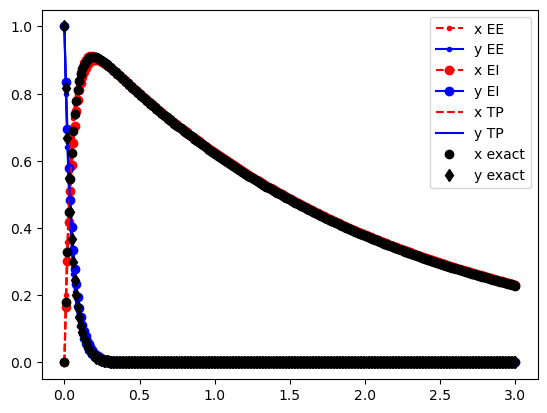

In [181]:
x, y = X[0,:], X[1,:]
plt.plot(t, x, 'r.--', label='x EE')
plt.plot(t, y, 'b.-', label='y EE')

x, y = Y[0,:], Y[1,:]
plt.plot(t, x, 'ro--', label='x EI')
plt.plot(t, y, 'bo-', label='y EI')

x, y = Z[0,:], Z[1,:]
plt.plot(t, x, 'r--', label='x TP')
plt.plot(t, y, 'b-', label='y TP')

plt.plot(t, x_exact, 'ko', label='x exact')
plt.plot(t, y_exact, 'kd', label='y exact')
plt.legend()
plt.show()

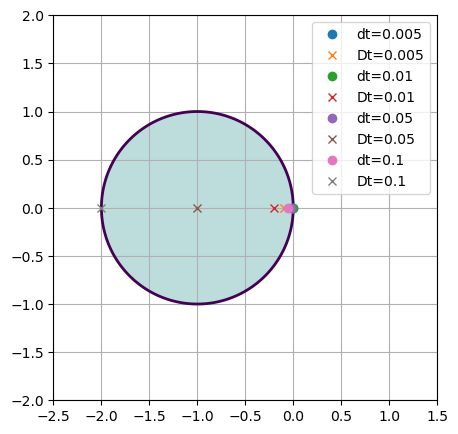

In [182]:
# Complex-plane grid
xr = np.linspace(-2.5, 1.5, 900)
yi = np.linspace(-2.0, 2.0, 900)
X, Y = np.meshgrid(xr, yi)
Z = X + 1j*Y

# Forward Euler stability function: R(z) = 1 + z
magR = np.abs(1 + Z)

# sample eigen values as an example

lambdas = np.array([-0.5, -20])
dt_list = [0.005, 0.01, 0.05, 0.1]

plt.figure(figsize=(4.95,5))
# Shade the stability set |1+z| < 1
plt.contourf(X, Y, magR, levels=[0, 1], alpha=0.3)
# Boundary circle |1+z| = 1
plt.contour(X, Y, magR, levels=[1], linewidths=2)
plt.grid(True)

for dt in dt_list:
    pts = dt * lambdas[0]
    plt.plot(pts.real, pts.imag, 'o', label=f'dt={dt}')

    pts = dt * lambdas[1]
    plt.plot(pts.real, pts.imag, 'x', label=f'Dt={dt}')



plt.legend()
plt.show()

Solve heat equation
$$
\frac{\partial u}{\partial t} = \nu\frac{\partial^2u}{\partial x^2}\quad x\in\mathbb R
$$

Exact solution
$$
u(x,t) = \frac{\sigma}{\sqrt{\sigma^2+2\nu t}}e^{\frac{-(x-x_0)^2}{\sqrt{\sigma^2+2\nu t}}}
$$

Trapezoidal method is called Crank-Nicolson method when it is applied to heat equation. The following code solves heat equation for $x\in[0,1]$. 

5.0


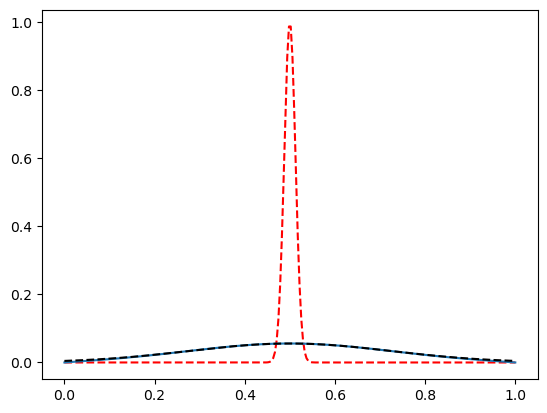

In [185]:
def solve_heat_eq(a, b, m, u0, t, nu, time_index=None):
    """ 
    Solve heat equation in [a, b]
    m is number of internal grid points
    u0 is initial condition on m+2 grid points
    u(a) = u(b) = 0
    t is time sequence
    
    this function returns u[:, time_index]
    """
    # step size
    dx = (b-a)/(m+1)

    dt = t[1]-t[0]
    nsteps = len(t) -1

    # FD parameter
    r = 0.5 * nu * dt /(dx *dx)

    # construct FD matrix A, so du/dt = Au is heat eq
    e = np.ones(m)

    A = np.diag(-2.0 * e) + np.diag(e[:-1], 1) + np.diag(e[:-1], -1)
    
    # Crank Nicolson matrices
    I = np.eye(m)

    A1 = I - r*A 
    A2 = I + r*A 

    # time marching
    u = np.zeros((m+2, nsteps + 1))
    
    # set initial condition
    u[:,0] = u0

    tn = 0.0
    for n in range(nsteps):
        tnp = tn + dt

        # Dirichlet BC
        g0n, g1n = u[0, n], u[-1, n]

        # interior
        uint = u[1:-1, n] # size m

        # rhs
        rhs = A2 @ uint
        rhs[0] += r * (g0n) # 0 for Dirichlet
        rhs[1] += r * (g1n) # 0 for Dirichlet

        uint_next = np.linalg.solve(A1, rhs)

        u[:, n+1] = np.concatenate(([0], uint_next, [0]))

        tn = tnp 

    return u






a, b = 0, 1.0
nu = 0.005
m = 256
x = np.linspace(a, b, m+2)
sig = 0.0125
x0 = 0.5
u = np.exp(-(x - x0)**2 / (2.0*sig**2))
#u = np.sin(np.pi*x)
plt.plot(x,u,'r--')
t = np.linspace(0, 5, 800)

#Gaussian exact
sig2 = sig**2 + 2.0*nu*t[-1]
amp = sig / np.sqrt(sig2)
u_exact = amp * np.exp(-(x - x0)**2 / (2.0 * sig2))

#u_exact = np.exp(-nu*np.pi**2*t[-1])*np.sin(np.pi*x)
u = solve_heat_eq(a, b, m, u, t, nu)
print(t[-1])
plt.plot(x,u[:,-1])
plt.plot(x,u_exact,'k--')
